In [46]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

In [ ]:
# Load survival data

survival = pd.read_excel("../Pupilometri/Left_manually_cleaned_artefacts.xlsx", sheet_name=0)

header = survival.columns
row = survival.iloc[6]

survival_df = pd.DataFrame([header, row.values]).T
survival_df.columns = survival_df.iloc[0]
survival_df = survival_df[1:].reset_index(drop=True)
survival_df = survival_df.dropna()

survival_df.rename(columns={'REDCap ID': 'record_id'}, inplace=True)


# Load features
df_features = pd.read_csv("../Modified_Pupilometri/pupilometry_features_right_noCHerror.csv")

df_t50 = pd.read_csv("../R_attempt/df_T50.csv")
df_t50['record_id'] = df_t50['pt_id'].str.replace('S_', '', regex=False)
df_t50['record_id'] = df_t50['record_id'].astype(int)
df_t50['redcap_repeat_instance'] = df_t50['day']
df_t50['eye'] = df_t50['lateral']
merged_df = df_features.merge(
    df_t50,
    on=['record_id', 'redcap_repeat_instance', 'eye'],
    how='left'
)

# map SECONDS category to numeric value
mapping_numeric = {
    "C": 0,
    "U": 1,
    "M-": 2,
    "M+": 3,
    "E": 4
}
merged_df["SECONDS"] = merged_df["SECONDS"].map(mapping_numeric)


In [48]:
survival_df['90-day survival'].value_counts()

90-day survival
Y    117
N    100
Name: count, dtype: int64

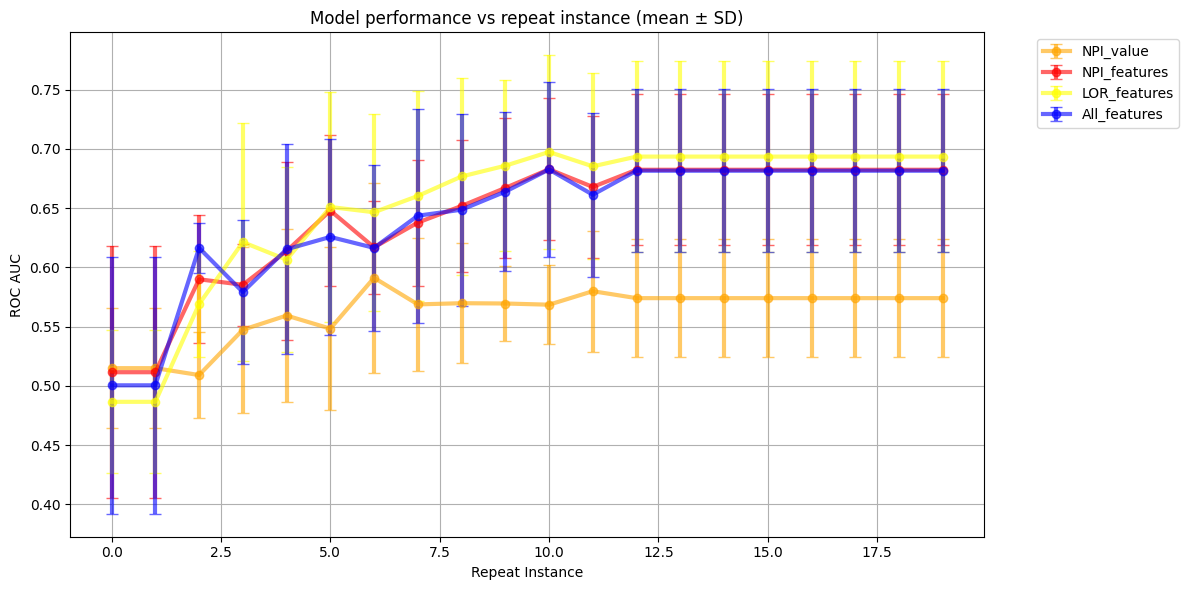

In [ ]:
# FOUR and SECONDS can be incluede or exclueded as wanted by the user

feature_cols = [
    "pupil_size",
    "pupil_min",
    "ch",
    "const_velocity",
    "dilat_velocity",
    "max_const_velocity",
    "latency",
    "LOR_early_gradient",
    "LOR_late_gradient",
    "pupil_dilation",
    "T50_dilat",
    #"FOUR_x",
    #"SECONDS",
    "npi"

]
NPI_features = [
    "pupil_size",
    "pupil_min",
    "ch",
    "const_velocity",
    "dilat_velocity",
    "max_const_velocity",
    "latency",
    #"FOUR_x",
    #"SECONDS"
]

Other_features = [
    "LOR_early_gradient",
    "LOR_late_gradient",
    "pupil_dilation",
    "T50_dilat",
    #"FOUR_x",
    #"SECONDS"
]


# Model and CV

model = LogisticRegression()

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Loop over repeat instances
repeat_range = range(0, 20)
auc_results = []

for target_repeat in repeat_range:

    df = merged_df.copy()

    # Keep only rows with all features non-missing
    df_valid = df.dropna(subset=feature_cols)

    if df_valid.empty:
        continue

    # Distance to target repeat
    df_valid["repeat_distance"] = abs(df_valid["redcap_repeat_instance"] - target_repeat)

    # Closest repeat per patient
    idx = df_valid.groupby("record_id")["repeat_distance"].idxmin()
    df_closest = df_valid.loc[idx]

    patient_features = df_closest.groupby("record_id")[feature_cols].mean().reset_index()

    # Merge survival
    df_final = pd.merge(patient_features, survival_df, on="record_id", how="inner")
    df_final = df_final.dropna()

    if df_final.empty:
        continue

    X_all = df_final[feature_cols].values
    y = df_final['90-day survival'].map({'Y':1, 'N':0}).values


    # ALL FEATURES
    scores = cross_val_score(pipe, X_all, y, cv=cv, scoring='roc_auc')
    auc_results.append({
        'repeat_instance': target_repeat,
        'feature': 'ALL_FEATURES',
        'AUC': scores.mean(),
        'STD': scores.std()
    })

    X_NPI = df_final[NPI_features].values
    scores = cross_val_score(pipe, X_NPI, y, cv=cv, scoring='roc_auc')
    auc_results.append({
        'repeat_instance': target_repeat,
        'feature': 'NPI_FEATURES',
        'AUC': scores.mean(),
        'STD': scores.std()
    })
    X_NPI_v = df_final[["npi"]].values
    scores = cross_val_score(pipe, X_NPI_v, y, cv=cv, scoring='roc_auc')
    auc_results.append({
        'repeat_instance': target_repeat,
        'feature': 'NPI_value_FEATURES',
        'AUC': scores.mean(),
        'STD': scores.std()
    })

    X_OTHER = df_final[Other_features].values
    y = df_final['90-day survival'].map({'Y':1, 'N':0}).values

    scores = cross_val_score(pipe, X_OTHER, y, cv=cv, scoring='roc_auc')
    auc_results.append({
        'repeat_instance': target_repeat,
        'feature': 'OTHER_FEATURES',
        'AUC': scores.mean(),
        'STD': scores.std()
    })


    # INDIVIDUAL FEATURES
    for feature in feature_cols:
        X_feat = df_final[[feature]].values

        scores = cross_val_score(pipe, X_feat, y, cv=cv, scoring='roc_auc')

        auc_results.append({
            'repeat_instance': target_repeat,
            'feature': feature,
            'AUC': scores.mean(),
            'STD': scores.std()
        })


# Convert results to dataframe
df_auc = pd.DataFrame(auc_results)

# Plot
plt.figure(figsize=(12,6))

NPI_f_v = df_auc[df_auc['feature'] == 'NPI_value_FEATURES']
plt.errorbar(
    NPI_f_v['repeat_instance'],
    NPI_f_v['AUC'],
    yerr=NPI_f_v['STD'],
    marker='o',
    linewidth=3,
    alpha=0.6, 
    color='orange',
    capsize=4,
    label='NPI_value'
)
NPI_f = df_auc[df_auc['feature'] == 'NPI_FEATURES']
plt.errorbar(
    NPI_f['repeat_instance'],
    NPI_f['AUC'],
    yerr=NPI_f['STD'],
    marker='o',
    linewidth=3,
    alpha=0.6, 
    color='red',
    capsize=4,
    label='NPI_features'
)


Other_f = df_auc[df_auc['feature'] == 'OTHER_FEATURES']
plt.errorbar(
     Other_f['repeat_instance'],
     Other_f['AUC'],
     yerr=Other_f['STD'],
     marker='o',
     linewidth=3,
     color='yellow',
     alpha=0.6, 
     capsize=4,
     label='LOR_features'
 )
# Combined model
combined = df_auc[df_auc['feature'] == 'ALL_FEATURES']
plt.errorbar(
    combined['repeat_instance'],
    combined['AUC'],
    yerr=combined['STD'],
    marker='o',
    linewidth=3,
    color='blue',
    alpha=0.6, 
    capsize=4,
    label='All_features'
)


plt.xlabel("Repeat Instance")
plt.ylabel("ROC AUC")
plt.title("Model performance vs repeat instance (mean ± SD)")
plt.grid()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Looking at performance for first (0) and last (19) repeat instance

In [ ]:
df_auc_filtered = df_auc[df_auc["repeat_instance"] == 19]

In [51]:
df_auc_filtered

,repeat_instance,feature,AUC,STD
304,19,ALL_FEATURES,0.681474,0.068714
305,19,NPI_FEATURES,0.682289,0.063729
306,19,NPI_value_FEATURES,0.573947,0.049571
307,19,OTHER_FEATURES,0.693407,0.080644
308,19,pupil_size,0.664443,0.108600
309,19,pupil_min,0.602376,0.093339
310,19,ch,0.664386,0.048989
311,19,const_velocity,0.663664,0.049474
312,19,dilat_velocity,0.698460,0.072768
313,19,max_const_velocity,0.675642,0.062568


In [52]:
df_auc_filtered = df_auc[df_auc["repeat_instance"] == 0]

In [53]:
df_auc_filtered

,repeat_instance,feature,AUC,STD
0,0,ALL_FEATURES,0.500385,0.108429
1,0,NPI_FEATURES,0.511421,0.106493
2,0,NPI_value_FEATURES,0.514857,0.050808
3,0,OTHER_FEATURES,0.486462,0.060391
4,0,pupil_size,0.449608,0.103199
5,0,pupil_min,0.438852,0.084772
6,0,ch,0.508728,0.039655
7,0,const_velocity,0.523184,0.092040
8,0,dilat_velocity,0.576449,0.062028
9,0,max_const_velocity,0.516095,0.082508
